In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [3]:
os.listdir('train/')

['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

In [4]:
emotions = {'angry':0, 'disgusted':1, 'fearful':2, 'happy':3, 'neutral':4, 'sad':5, 'surprised':6}

In [7]:
X_train = []
y_train = []
for i in os.listdir('train/'):
    for j in os.listdir(f'train/{i}/'):
        image = mpimg.imread(f'train/{i}/{j}')
        image = image.reshape(48, 48, 1)
        X_train.append(image)
        y_train.append(emotions[i])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [8]:
X_test = []
y_test = []
for i in os.listdir('test/'):
    for j in os.listdir(f'test/{i}/'):
        image = mpimg.imread(f'test/{i}/{j}')
        image = image.reshape(48, 48, 1)
        X_test.append(image)
        y_test.append(emotions[i])
X_test = np.array(X_test)
y_test = np.array(y_test)

In [9]:
X_train.shape

(28709, 48, 48, 1)

In [10]:
y_train.shape

(28709,)

In [11]:
X_test.shape

(7178, 48, 48, 1)

In [12]:
y_test.shape

(7178,)

In [13]:
from keras.utils import to_categorical

In [14]:
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [18]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

In [22]:
model = Sequential()
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu'))

model.add(Flatten())

model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(7, activation='softmax'))


C:\Users\ASUS\Desktop\ml_16-40\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15)

Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.3003 - loss: 1.7358 - val_accuracy: 0.3657 - val_loss: 1.6354
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.3817 - loss: 1.5695 - val_accuracy: 0.4065 - val_loss: 1.5134
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 35ms/step - accuracy: 0.4125 - loss: 1.4921 - val_accuracy: 0.4329 - val_loss: 1.4459
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.4441 - loss: 1.4215 - val_accuracy: 0.4510 - val_loss: 1.4076
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.4687 - loss: 1.3599 - val_accuracy: 0.4536 - val_loss: 1.4000
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.4895 - loss: 1.3113 - val_accuracy: 0.4696 - val_loss: 1.3747
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5060 - loss: 1.2715 - val_accuracy: 0.4730 - val_loss: 1.3765
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.5216 - loss: 1.2323 - 

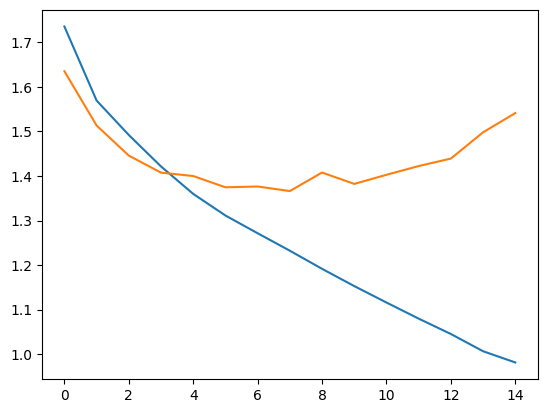

In [25]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

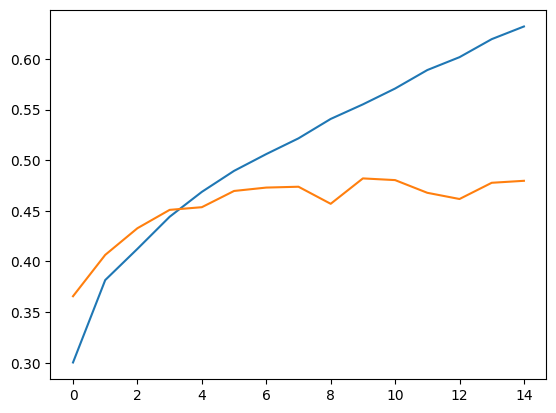

In [26]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [28]:
mpimg.imread('train/angry/im0.png')

array([[0.27450982, 0.3137255 , 0.32156864, ..., 0.20392157, 0.16862746,
        0.16078432],
       [0.25490198, 0.23921569, 0.22745098, ..., 0.21960784, 0.20392157,
        0.17254902],
       [0.19607843, 0.16862746, 0.21176471, ..., 0.19215687, 0.21960784,
        0.18431373],
       ...,
       [0.35686275, 0.25490198, 0.16470589, ..., 0.28235295, 0.21960784,
        0.16862746],
       [0.3019608 , 0.32156864, 0.30980393, ..., 0.4117647 , 0.27450982,
        0.18039216],
       [0.3019608 , 0.28235295, 0.32941177, ..., 0.41568628, 0.42745098,
        0.32156864]], shape=(48, 48), dtype=float32)

In [29]:
import pickle

In [30]:
with open('emotion_model.pkl', 'wb') as file:
    pickle.dump(model, file)